In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"  # must be set before importing jax
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from furax.interfaces.sotodlib import SOTODLibObservation

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [3]:
# Directories
no_hwpss_dir = Path("/pscratch/sd/b/binguyen/so-sat/preprocessing_exploratory_files")
hwpss_dir = no_hwpss_dir / "processed_with_mask"

# Identifiers
obs_id = "obs_1723956370_satp3_1111111"
ws = "ws0"
f = "f150"

In [4]:
def get_hwpss_model(obs_id, ws, f="f150"):    
    filename = f"aman_{obs_id}_{ws}_{f}.h5"
    
    aman_file = no_hwpss_dir / filename
    aman_hwpss_file = hwpss_dir / filename
    
    obs_no_hwpss = SOTODLibObservation.from_file(aman_file)
    obs_hwpss = SOTODLibObservation.from_file(aman_hwpss_file)
    
    tod_no_hwpss = obs_no_hwpss.get_tods().astype(np.float32)
    tod_hwpss = obs_hwpss.get_tods().astype(np.float32)
    
    hwpss = tod_no_hwpss - tod_hwpss
    
    time = np.array(obs_hwpss.get_elapsed_times()).astype(np.float32)
    
    return time, hwpss

In [5]:
hwpss = get_hwpss_model(obs_id, ws)

In [8]:
time, hwpss = hwpss

In [11]:
ndet, nsamp = hwpss.shape

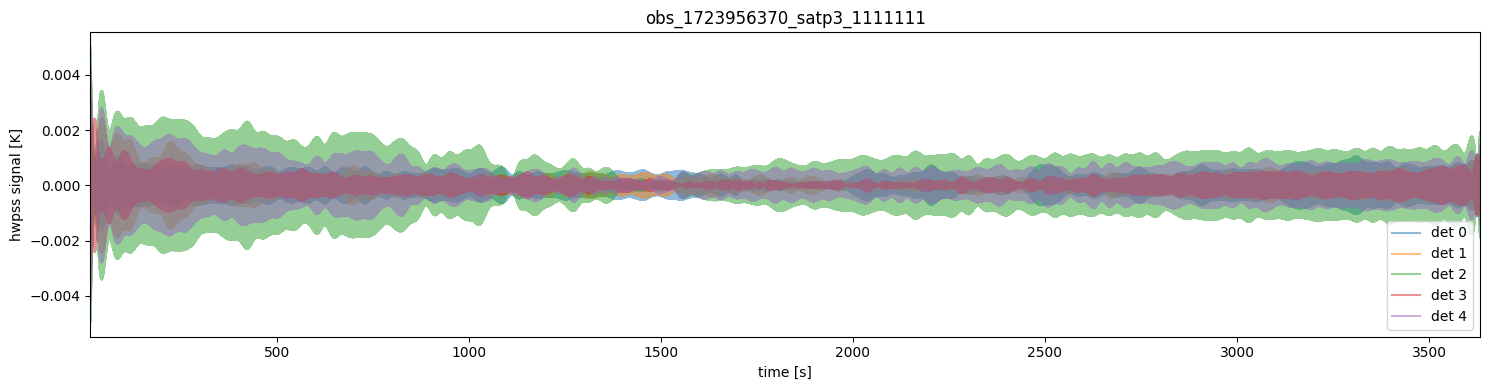

In [14]:
i, f = 3000, nsamp - 1000

plt.figure(figsize=(15,4))
for j in range(5):
    plt.plot(time[i:f], hwpss[j][i:f], alpha=0.5, label=f"det {j}")

plt.xlabel("time [s]")
plt.ylabel("hwpss signal [K]")
plt.legend(loc="lower right")
plt.title(f"{obs_id}")

plt.xlim(time[i], time[f])
plt.tight_layout()
plt.savefig(f"../figures/{obs_id}_hwpss_model")
plt.show()
plt.close()

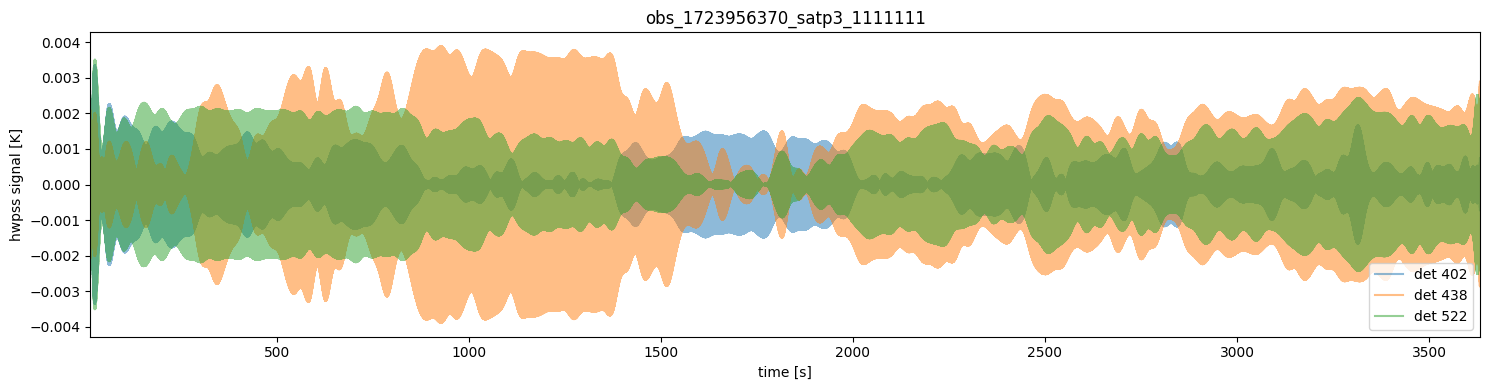

In [17]:
# Randomly select 5 detectors without replacement
dets = np.random.choice(ndet, size=3, replace=False)

plt.figure(figsize=(15, 4))

for det in dets:
    plt.plot(
        time[i:f],
        hwpss[det, i:f],
        alpha=0.5,
        label=f"det {det}"
    )

plt.xlabel("time [s]")
plt.ylabel("hwpss signal [K]")
plt.legend(loc="lower right")
plt.title(obs_id)

plt.xlim(time[i], time[f-1])
plt.tight_layout()
plt.savefig(f"../figures/{obs_id}_hwpss_model_3random_2.png")
plt.show()
plt.close()